# Using manual dataset generated by make_blobs


In [1]:
import sklearn
import numpy as np
import os

np.random.seed(42)


import matplotlib as mpl
from sklearn.metrics import pairwise_distances
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "kmeans"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="pdf", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Generate dataset


In [2]:
from sklearn.datasets import make_blobs

blob_centers = np.array(
    [[ 0.2,  2.3],
     [-1.5 ,  2.3],
     [-2.8,  1.8],
     [-2.8,  2.8],
     [-2.8,  1.3],
     [-0.5,  1.5]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1, 0.15])

X, y = make_blobs(n_samples=3000, centers=blob_centers,
                  cluster_std=blob_std, random_state=7)

In [3]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

Saving figure blobs_diagram


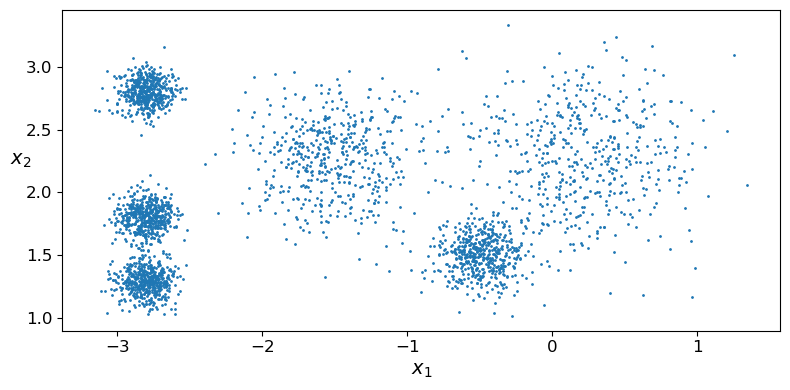

In [4]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
save_fig("blobs_diagram")
plt.show()

Saving figure 2dKDE


C:\Users\dell\AppData\Local\Temp\ipykernel_1832\636252676.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


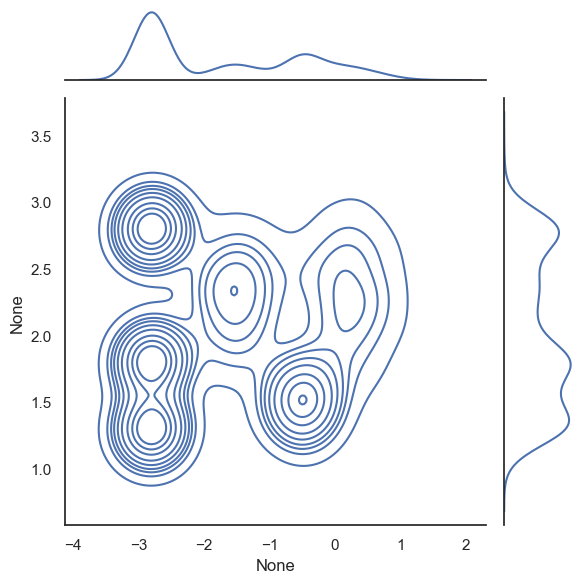

In [5]:
x_coords = [coord[0] for coord in X]
y_coords = [coord[1] for coord in X]

sns.set(style="white", color_codes=True)
g = sns.jointplot(x=x_coords, y=y_coords, kind="kde", space=0, color="b")
save_fig("2dKDE")
plt.show()

# Fit and Predict


In [6]:
from sklearn.cluster import KMeans

In [7]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)
kmeans.labels_

array([2, 5, 2, ..., 0, 2, 3])

In [8]:
kmeans.cluster_centers_

array([[-0.47322574,  1.52680578],
       [-2.79695183,  1.80602402],
       [-1.50412048,  2.28635375],
       [-2.79448454,  2.79734389],
       [ 0.25164199,  2.3406275 ],
       [-2.799667  ,  1.29156584]])

In [9]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([4, 4, 3, 3])

# Decision Boundaries


In [10]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=5, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True, show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

def plot_similarity_matrix(clusterer, X, n_samples=100, cmap="YlGnBu"):
    # Randomly select a subset of samples
    random_indices = np.random.choice(X.shape[0], n_samples, replace=False)
    sampled_X = X[random_indices]

    # Use the provided clusterer to predict labels
    labels = clusterer.predict(sampled_X)

    # Compute the similarity matrix
    similarity_matrix = 1 - pairwise_distances(sampled_X, metric='euclidean') / np.max(pairwise_distances(sampled_X, metric='euclidean'))

    # Sort the samples based on cluster labels
    order = np.argsort(labels)
    similarity_matrix = similarity_matrix[order][:, order]

    # Plot the similarity matrix using Seaborn heatmap
    sns.set(font_scale=1.2)
    plt.figure(figsize=(8, 8))
    sns.heatmap(similarity_matrix, cmap=cmap, square=True, cbar=False)

    plt.title("Similarity Matrix Heatmap (Clustered Data)")

In [11]:
def plot_color_clusters(X, y, center):
    unique_labels = np.unique(y)

    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
    plot_centroids(center)
    for label, color in zip(unique_labels, colors):
        class_points = X[y == label]
        plt.scatter(class_points[:, 0], class_points[:, 1], color=color, label=f'Cluster {label}')

    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$', rotation=0)
    #plt.title('Clustered Data')


Saving figure voronoi_diagram


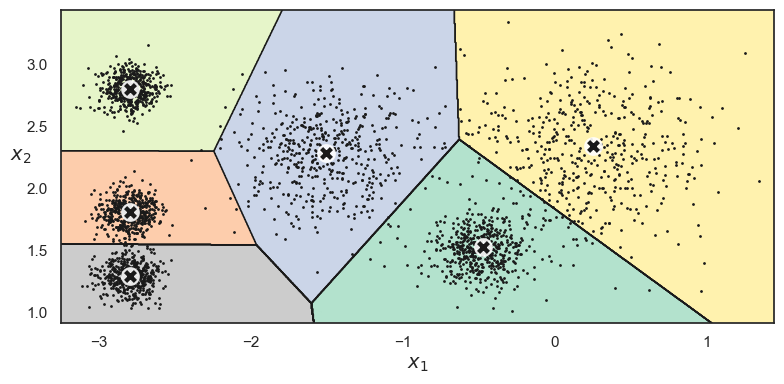

In [12]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
save_fig("voronoi_diagram")
plt.show()

Saving figure color_scatter


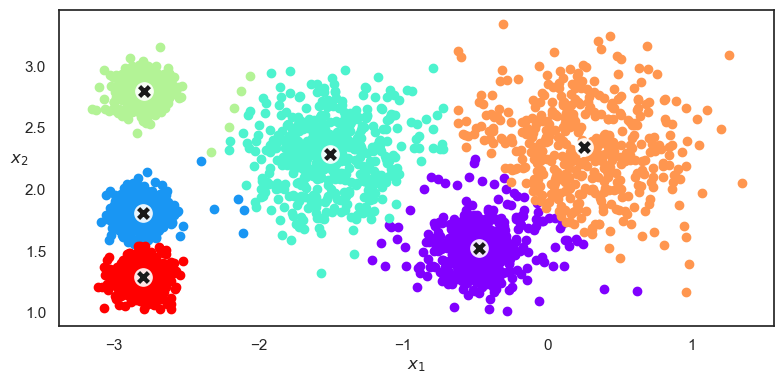

In [13]:
plt.figure(figsize=(8, 4))
plot_color_clusters(X, kmeans.labels_, kmeans.cluster_centers_)
save_fig("color_scatter")
plt.show()

Saving figure Similarity Matrix Heatmap


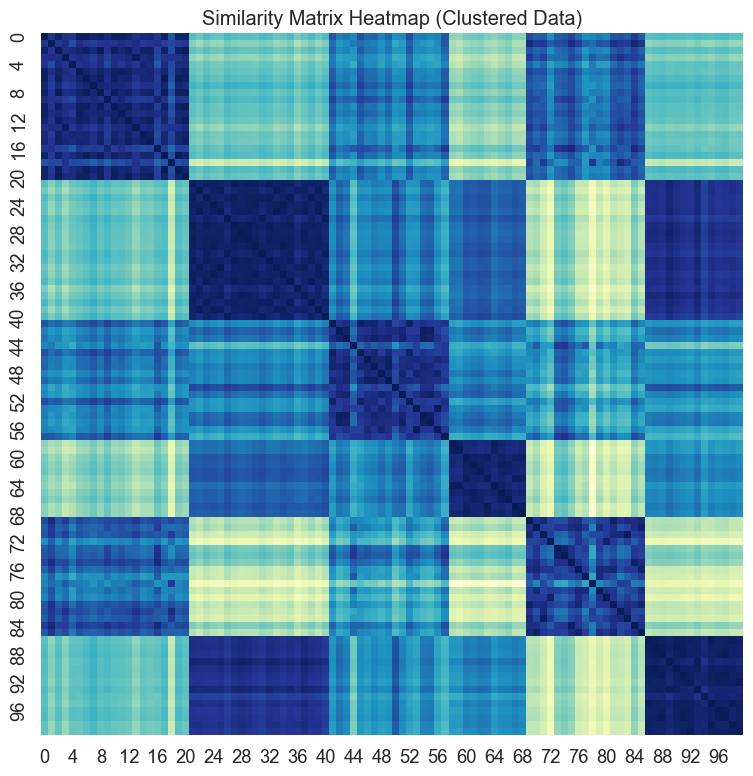

In [14]:
plot_similarity_matrix(kmeans, X)
save_fig('Similarity Matrix Heatmap')
plt.show()

In [15]:
kmeans_iter1 = KMeans(n_clusters=k, init="random", n_init=2,
                     algorithm='lloyd', max_iter=1, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="random", n_init=2,
                     algorithm='lloyd', max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="random", n_init=2,
                     algorithm='lloyd', max_iter=3, random_state=1)

kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(init='random', max_iter=3, n_clusters=6, n_init=2, random_state=1)

Saving figure kmeans_algorithm_diagram


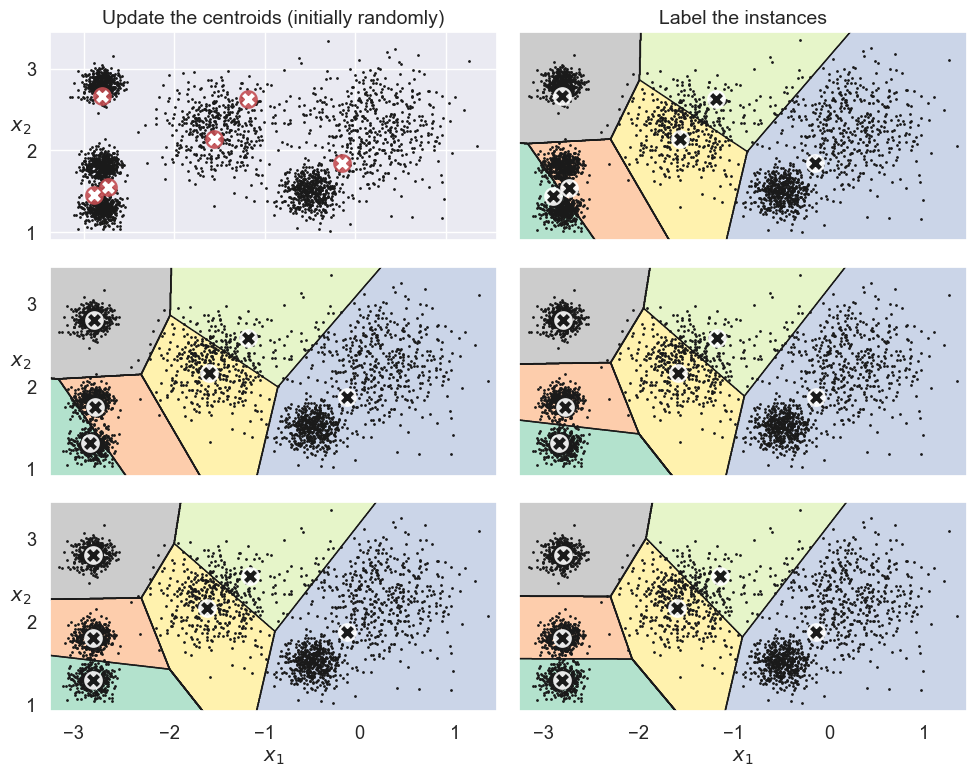

In [16]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

save_fig("kmeans_algorithm_diagram")
plt.show()

In [17]:
kmeans_iter1_pp = KMeans(n_clusters=k, n_init=2,
                     algorithm='lloyd', max_iter=1, random_state=1)
kmeans_iter2_pp = KMeans(n_clusters=k, n_init=2,
                     algorithm='lloyd', max_iter=2, random_state=1)
kmeans_iter3_pp = KMeans(n_clusters=k, n_init=2,
                     algorithm='lloyd', max_iter=3, random_state=1)

kmeans_iter1_pp.fit(X)
kmeans_iter2_pp.fit(X)
kmeans_iter3_pp.fit(X)

KMeans(max_iter=3, n_clusters=6, n_init=2, random_state=1)

Saving figure kmeans++_algorithm_diagram


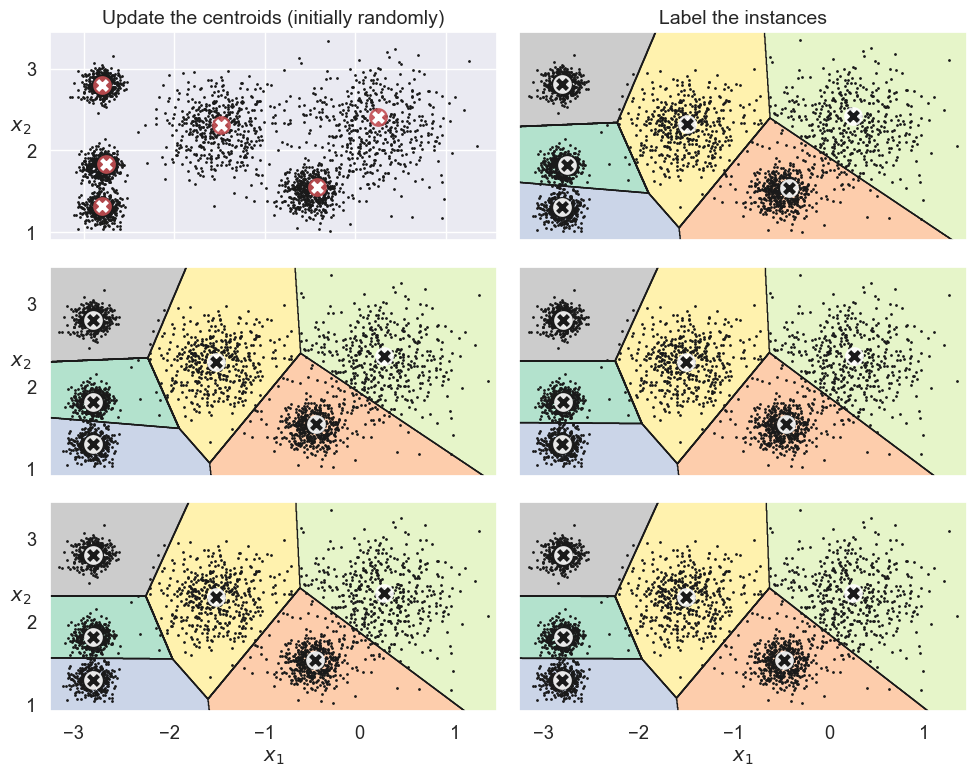

In [18]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1_pp.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1_pp, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1_pp, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2_pp.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2_pp, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2_pp, X, show_centroids=False)
plot_centroids(kmeans_iter3_pp.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3_pp, X, show_ylabels=False)

save_fig("kmeans++_algorithm_diagram")
plt.show()

In [19]:
kmeans_rnd_10_inits = KMeans(n_clusters=6, init="random", n_init=10,
                              algorithm='lloyd', random_state=11)
kmeans_rnd_10_inits.fit(X)

KMeans(init='random', n_clusters=6, n_init=10, random_state=11)

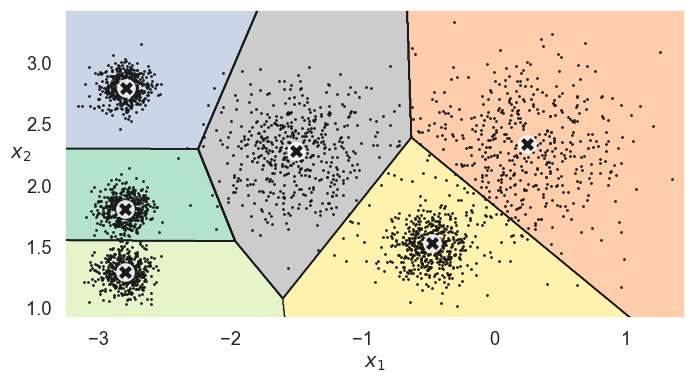

In [20]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

# Comparison


In [21]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

# Evaluation


# Finding the optimal number of clusters


Saving figure bad_n_clusters_diagram


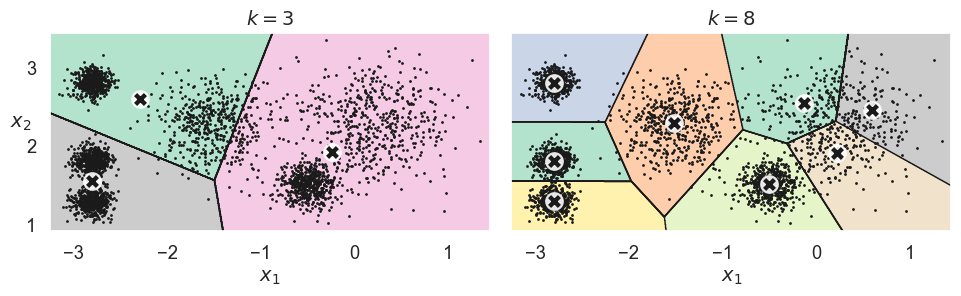

In [22]:
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_k8 = KMeans(n_clusters=8, random_state=42, n_init=10)

plot_clusterer_comparison(kmeans_k3, kmeans_k8, X, "$k=3$", "$k=8$")
save_fig("bad_n_clusters_diagram")
plt.show()

### Inertia


In [23]:
kmeans.inertia_

266.7415429316401

In [24]:
X_dist = kmeans.transform(X)
np.sum(X_dist[np.arange(len(X_dist)), kmeans.labels_]**2)

266.74154293164065

In [25]:
kmeans.score(X)

-266.7415429316401

In [26]:
kmeans_k3.inertia_

1060.1280340785001

In [27]:
kmeans_k8.inertia_

194.0773225677428

In [28]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

Saving figure inertia_vs_k_diagram


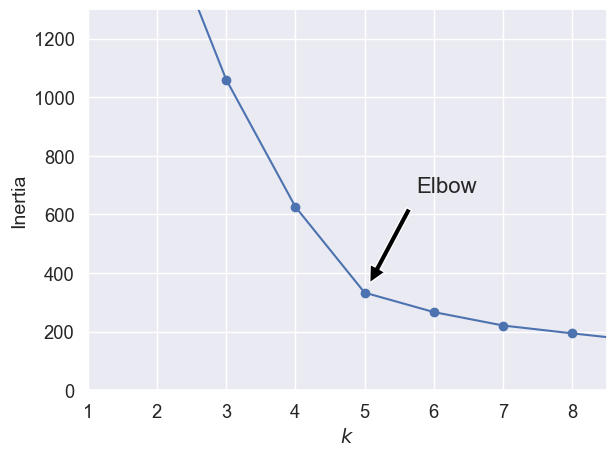

In [29]:
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow',
             xy=(5, inertias[4]),
             xytext=(0.65, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.axis([1, 8.5, 0, 1300])
save_fig("inertia_vs_k_diagram")
plt.show()

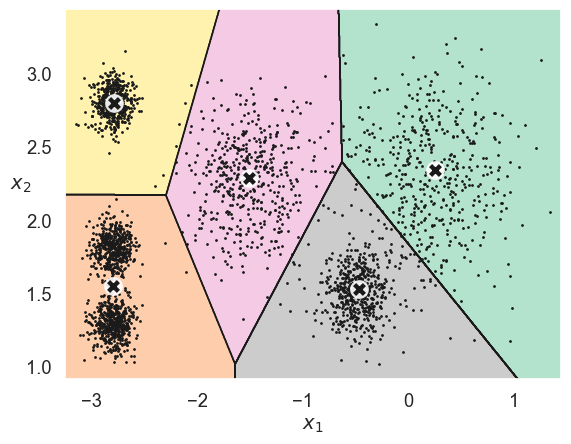

In [30]:
plot_decision_boundaries(kmeans_per_k[5-1], X)
plt.show()

### Silhouette Coefficient


In [31]:
from sklearn.metrics import silhouette_score

In [32]:
silhouette_score(X, kmeans.labels_)

0.6343972060269748

In [33]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

Saving figure silhouette_score_vs_k_diagram


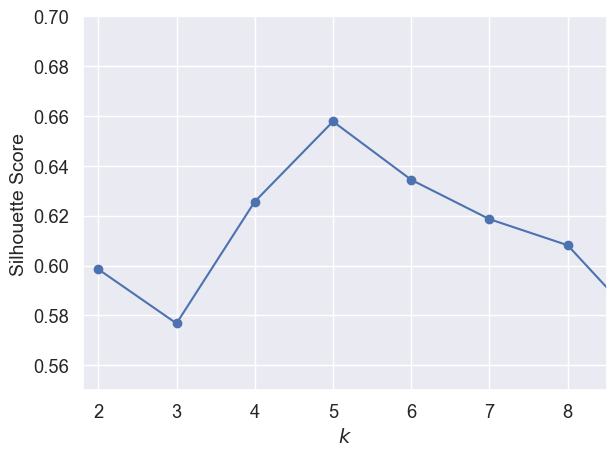

In [34]:
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)
plt.axis([1.8, 8.5, 0.55, 0.7])
save_fig("silhouette_score_vs_k_diagram")
plt.show()

Saving figure silhouette_analysis_diagram


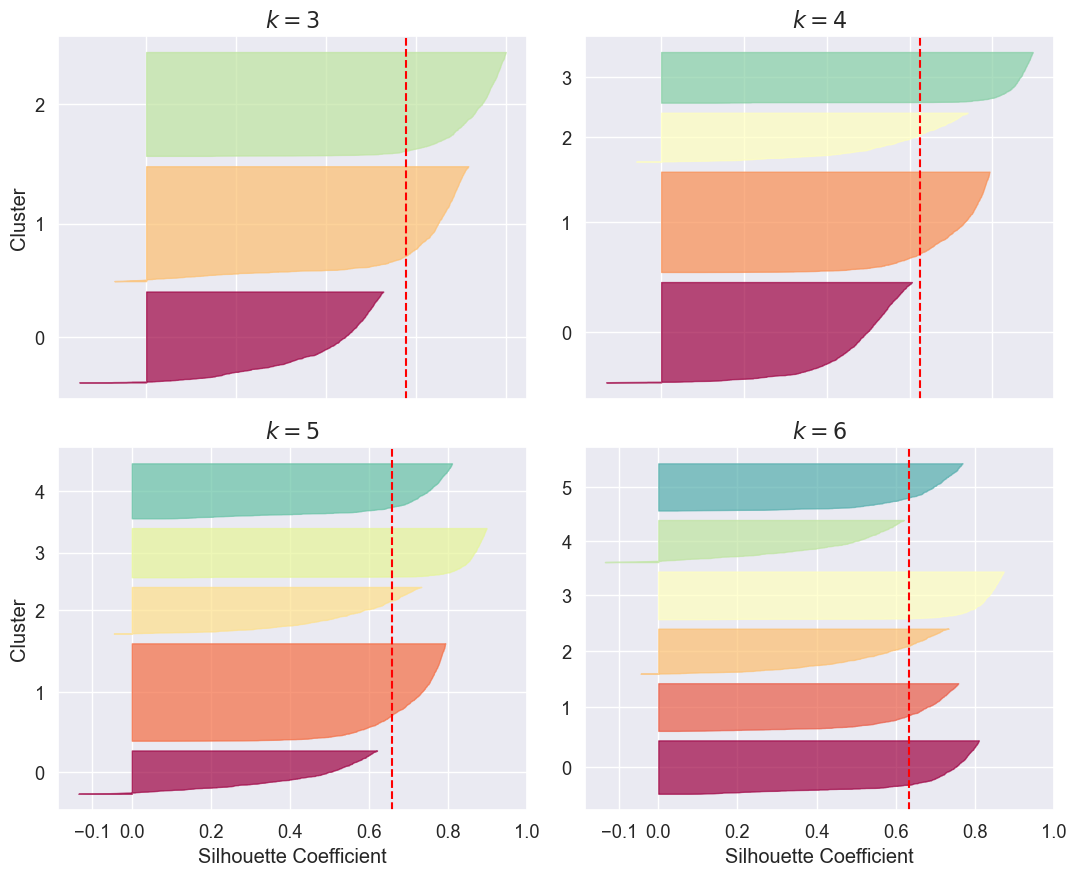

In [35]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)
    
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")
    
    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

save_fig("silhouette_analysis_diagram")
plt.show()

### Calinski-Harabasz Index


In [36]:
from sklearn.metrics import calinski_harabasz_score
calinski_harabasz_index = calinski_harabasz_score(X, kmeans.labels_)
calinski_harabasz_index

11656.232908612646

Saving figure calinski_harabasz_score_vs_k_diagram


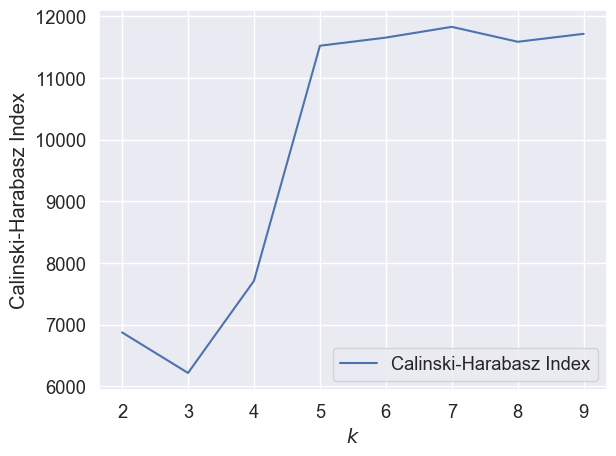

In [37]:
n_clusters_range = range(2, 10)
ch_scores = []

for n_clusters in n_clusters_range:
    kmeans = KMeans(n_clusters=n_clusters,n_init=10)
    predicted_labels = kmeans.fit_predict(X)

    ch_score = calinski_harabasz_score(X, predicted_labels)
    ch_scores.append(ch_score)

plt.plot(n_clusters_range, ch_scores, label='Calinski-Harabasz Index')
plt.xlabel("$k$", fontsize=14)
plt.ylabel('Calinski-Harabasz Index')
plt.legend()
save_fig("calinski_harabasz_score_vs_k_diagram")
plt.show()

### Davies-Bouldin Index


In [38]:
from sklearn.metrics import davies_bouldin_score
davies_bouldin_index = davies_bouldin_score(X, kmeans.labels_)
davies_bouldin_index

0.7804695784315872

Saving figure davies_bouldin_score_vs_k_diagram


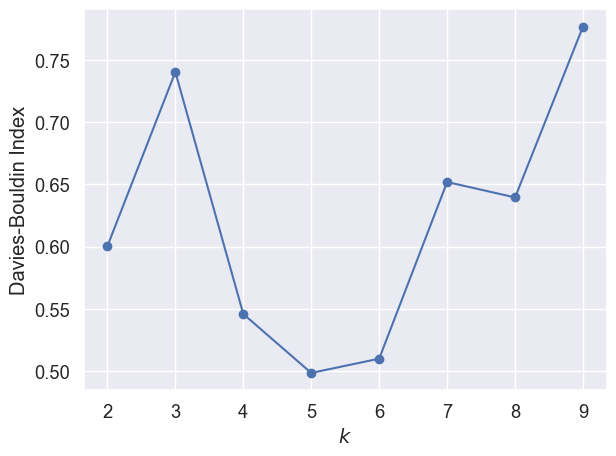

In [39]:
# 尝试不同的簇数
max_clusters = 10
cluster_range = range(2, max_clusters)
davies_bouldin_scores = []

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    predicted_labels = kmeans.fit_predict(X)
    davies_bouldin_score_value = davies_bouldin_score(X, predicted_labels)
    davies_bouldin_scores.append(davies_bouldin_score_value)

# 绘制 Davies-Bouldin Index 随簇数变化的图表
plt.plot(cluster_range, davies_bouldin_scores, marker='o')
plt.xlabel("$k$", fontsize=14)
plt.ylabel('Davies-Bouldin Index')
#plt.title('Davies-Bouldin Index vs. Number of Clusters')
save_fig("davies_bouldin_score_vs_k_diagram")
plt.show()

# Limitation


In [40]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X_mix = np.r_[X1, X2]
y_mix = np.r_[y1, y2]

Saving figure ellipsoidal


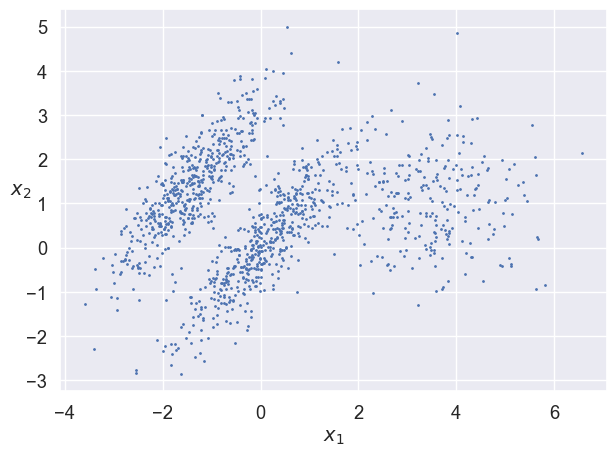

In [41]:
plot_clusters(X_mix)
save_fig("ellipsoidal")
plt.show()

In [42]:
kmeans_good = KMeans(n_clusters=3, init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]), n_init=1, random_state=42)
kmeans_bad = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_good.fit(X_mix)
kmeans_bad.fit(X_mix)

KMeans(n_clusters=3, n_init=10, random_state=42)

Saving figure bad_kmeans_diagram


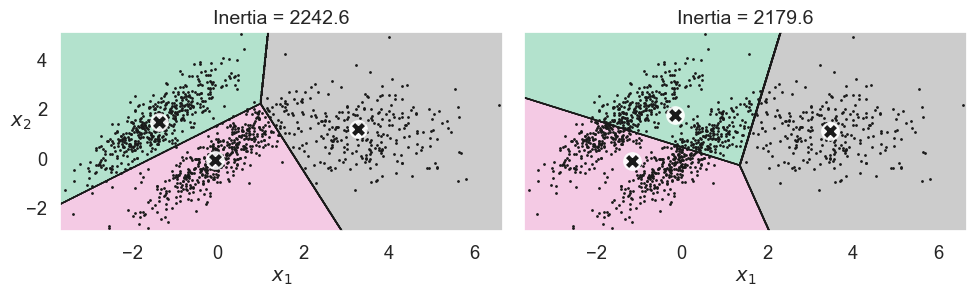

In [43]:
plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plot_decision_boundaries(kmeans_good, X_mix)
plt.title("Inertia = {:.1f}".format(kmeans_good.inertia_), fontsize=14)

plt.subplot(122)
plot_decision_boundaries(kmeans_bad, X_mix, show_ylabels=False)
plt.title("Inertia = {:.1f}".format(kmeans_bad.inertia_), fontsize=14)

save_fig("bad_kmeans_diagram")
plt.show()